# **Business Problem**

---



Retail Companies need to understand the customer purchasing behavior, seasonal trends and top selling products.

**Objective:**

Identify:


*   Peak Sales Hours
*   Peak Sales Month


*   Customer Purchasing Patterns
*   Top Selling Products





## **Import Libraries**

---



Import essential libraries


*   **pandas** for data manipulation

*   **numpy** for numerical value


*   **matplotlib.pyplot** for plotting

*   **seaborn**  for enhanced visualizations




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Import Dataset**
---


A CSV file named *data.csv*  is loaded into the pandas DataFrame *df*.

In [2]:
df = pd.read_csv('data.csv', encoding='latin1')

### **Intial Exploration:**

The commands like head(), tail(), isnull().sum(), describe() and dtypes()  are used to inspect first/last row, checking missing values, summarize and review the data types of each columns

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.tail()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
188069,553013,23201,JUMBO BAG ALPHABET,1,5/12/2011 18:19,4.13,NaN,United Kingdom
188070,553013,23204,CHARLOTTE BAG APPLES DESIGN,2,5/12/2011 18:19,1.63,NaN,United Kingdom
188071,553013,23207,LUNCH BAG ALPHABET DESIGN,1,5/12/2011 18:19,4.13,NaN,United Kingdom
188072,553013,23209,LUNCH BAG DOILEY PATTERN,2,5/12/2011 18:19,4.13,NaN,United Kingdom
188073,553013,23298,SPOTTY BUNTING,1,5/12/2011 18:19,10.79,NaN,United Kingdom


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,188074.000000,188074.000000,132166.000000
mean,9.202053,5.046372,15268.030454
std,247.886591,97.125476,1725.782678
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13819.000000
50%,3.000000,2.130000,15135.000000
75%,10.000000,4.210000,16791.750000
max,74215.000000,16888.020000,18283.000000


**Sum of Null Values**

In [6]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,763
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,55908
Country,0


**Columns Types**

In [7]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


## **Data Cleaning & Feature Engineering**

---



### **Drop Unnecessary Columns from Dataset**

The project focused on data cleaning and feature engineering to ensure the dataset was structured appropriately for meaningful analysis and visualization.

Several columns that did not contribute directly to the sales analysis, including **InvoiceNo, CustomerID, StockCode, and Country**, were removed to simplify the dataset and reduce unnecessary complexity.

In [8]:
df= df.drop(columns=['InvoiceNo', 'CustomerID','StockCode','Country'])

In [9]:
print(df.columns)


Index(['Description', 'Quantity', 'InvoiceDate', 'UnitPrice'], dtype='object')


### **Extract Columns**

The InvoiceDate column was converted into a datetime format to enable efficient manipulation of time-based information. Using datetime functions, multiple features were extracted to support temporal analysis:


1.   **Month** used for identifying seasonal sales trends
and monthly performance.
2.   **Date** used for day-level analysis.

1.  **Time** extracted for detailed time-based analysis.
2.   **Hours** derived from the time column to represent the hour of the day and identify peak operational periods.








In [10]:
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
df['Month']= df['InvoiceDate'].dt.month_name()
df['Date']= df['InvoiceDate'].dt.day
df['Time']= df['InvoiceDate'].dt.time

print(df.columns)

Index(['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'Month', 'Date',
       'Time'],
      dtype='object')


### **Sales Column**

A new feature called **Sales** was created by following calculation:

 **Sales = Quantity * UnitPrice**

This column represent the revenue generated for each transaction and serve as a primary variables used throughout the analysis.

In [11]:
df['Sales']= df['Quantity']*df['UnitPrice']

### **Reorganized Columns**

For consistency and improved readability;


*   Columns were reorganized into a more structured format.
*   Data types for Sales and UnitPrice were refined and converted into appropriate numerical formats.


*   Additional preprocessing steps ensured that the
dataset was prepared for visualization and correlation analysis


In [12]:
desired_column_order = ['Date','Time','Month','Description','Quantity','UnitPrice','Sales']
df = df[desired_column_order]

In [13]:
print('Current DataFrame columns:')
print(df.columns)


Current DataFrame columns:
Index(['Date', 'Time', 'Month', 'Description', 'Quantity', 'UnitPrice',
       'Sales'],
      dtype='object')


### **Refining the Numbers**

In [14]:
print(df.dtypes)
df['Sales']= df['Sales'].astype(int)
df['UnitPrice']= df['UnitPrice'].astype(int)

Date             int32
Time            object
Month           object
Description     object
Quantity         int64
UnitPrice      float64
Sales          float64
dtype: object


# **EDA & Data Visualizations**

---

To uncover meaningful business insights, multiple visualizations were developed to analyze sales behavior across time and products.

### **Line Chart**

Line chart was generated to analyze total sales across different hours of the day.
This charts helped us to identify the busiest times of the day (e.g., 10 AM to 3 PM) when sales were highest, which can inform staffing, inventory management, and promotional activities.



In [15]:
df['Hours']=df['Time'].apply(lambda x:x.hour)

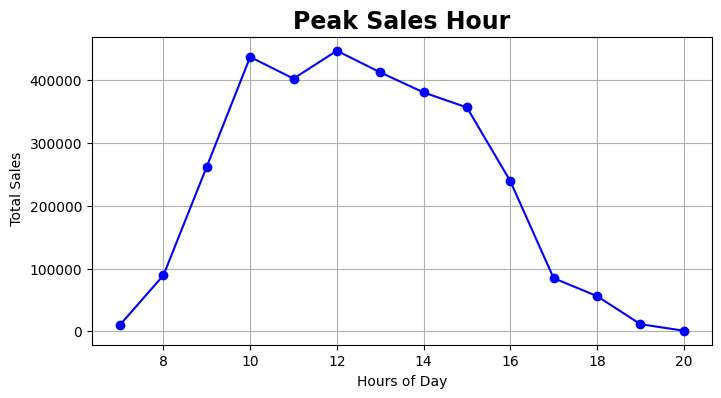

In [34]:
Peak_Sales= df.groupby('Hours')['Sales'].sum()

plt.figure(figsize=(8,4))

plt.plot(
    Peak_Sales.index,
    Peak_Sales.values,
    marker='o',
    linestyle='-',
    color='b'
)

plt.title('Peak Sales Hour', fontsize=17, fontweight='bold')
plt.xlabel('Hours of Day')
plt.ylabel(' Total Sales')
plt.grid(True)



Here, I used Plotly line chart to provide more dynamic exploration of hourly sales performance.

It helps user to hovour over specific points, view exact sales and explore trends in greater details.   



In [36]:
import plotly.express as px

Peak_Sales= df.groupby('Hours')['Sales'].sum().reset_index()
plt.figure(figsize=(5,4))
fig = px.line(Peak_Sales, x='Hours', y='Sales',markers=True, title='Peak Sales Hour')

fig.show()

<Figure size 500x400 with 0 Axes>

### **Bar Chart - Peak Sales Hours**

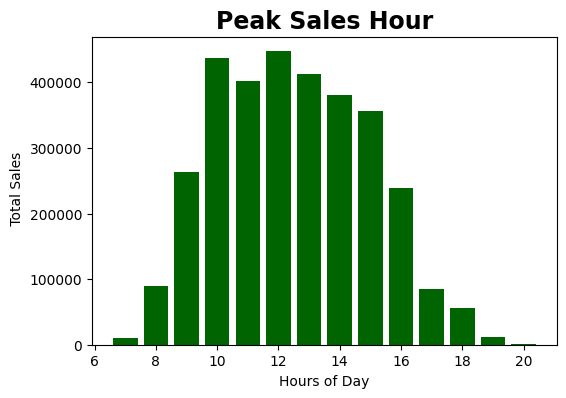

In [31]:
df['Hours']=df['Time'].apply(lambda x:x.hour)
Peak_Sales= df.groupby('Hours')['Sales'].sum()
Peak_Sales= Peak_Sales.sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(Peak_Sales.index,
        Peak_Sales.values,color='darkgreen')
plt.title('Peak Sales Hour', fontsize=17, fontweight='bold')
plt.xlabel('Hours of Day')
plt.ylabel(' Total Sales')
plt.grid(False)

plt.show()

### **Heatmap**

Heatmap was generated to visualize the relationship between two categorical variables(Month & Hours) and their impact on a continuos variable (Sales).
It helps pinpoint specific months and hours that are exceptionally strong or weak, providing a granular view of sales performance.

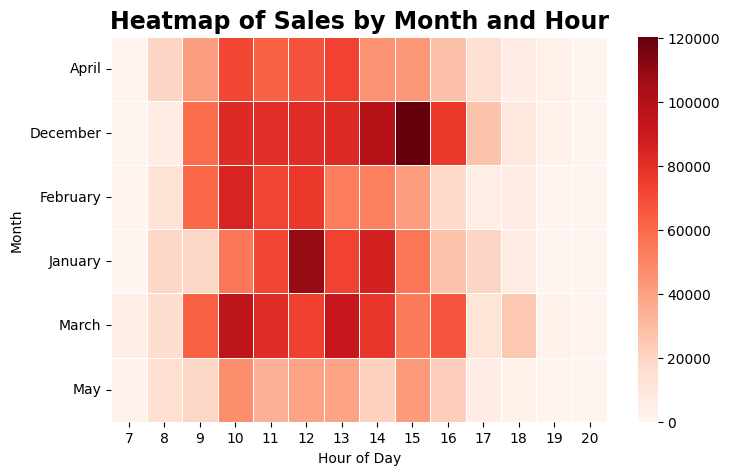

In [29]:
# Create a pivot table for the heatmap
heatmap_data = df.pivot_table(index='Month', columns='Hours', values='Sales', aggfunc='sum')

# Fill any potential NaN values with 0 for better visualization if there are missing hours/months
heatmap_data = heatmap_data.fillna(0)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, cmap='Reds', fmt='.0f', linewidths=.5)
plt.title('Heatmap of Sales by Month and Hour', fontsize=17, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Month')
plt.show()

### **Bar Chart - Peak Sales Per Month**

A monthly sales bar chart was created to analyze seasonal performance and identify high-performing periods.

This visualization helps determine:


*   Months generating the highest revenue
*   Seasonal trends


*   Monthly fluctuations in business activity

Understanding seasonal patterns enables organizations to prepare inventory and marketing strategies accordingly.

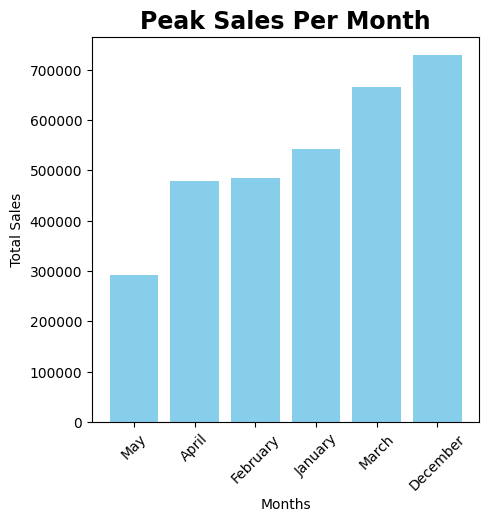

In [27]:

Peak_Sales= df.groupby('Month')['Sales'].sum()
Peak_Sales= Peak_Sales.sort_values(ascending=True)

plt.figure(figsize=(5,5))
plt.bar(Peak_Sales.index,
        Peak_Sales.values,color='skyblue')
plt.title('Peak Sales Per Month', fontsize=17, fontweight='bold')
plt.xlabel('Months')
plt.ylabel(' Total Sales ')
plt.xticks(rotation=45)
plt.grid(False)

plt.show()

### **Pie Chart - Top Selling Products**

Pie chart was developeed to display the contribution of top 10 products to total sales.

This visualization helps us in us to identify:


*   Best selling Products
*   Which products generate most revenue


*   Product categories requiring greater business focus






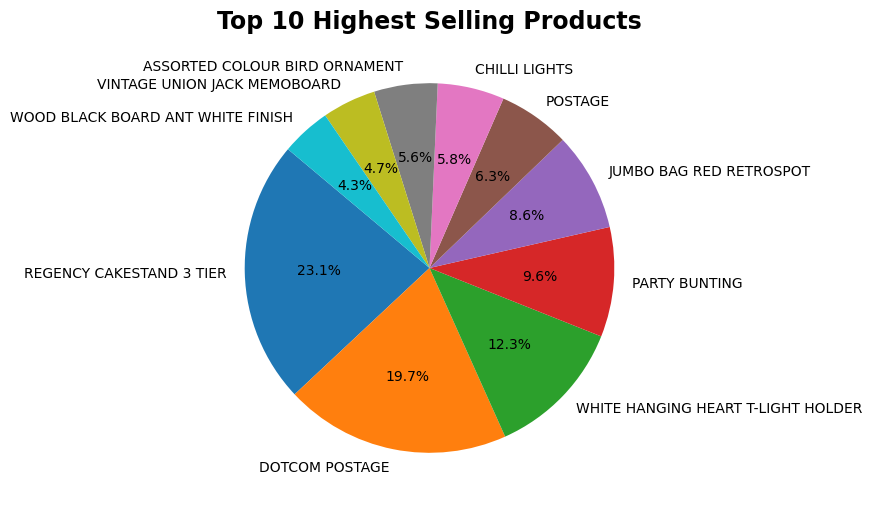

In [37]:
product_catogory_sales = df.groupby('Description')['Sales'].sum()

# Filter out negative or zero sales to avoid ValueError in pie chart
product_catogory_sales = product_catogory_sales[product_catogory_sales > 0]

# Optional: Select top N categories if the number of unique descriptions is very large
# For example, top 10
product_catogory_sales = product_catogory_sales.nlargest(10)

plt.figure(figsize=(6,6))

plt.pie(
    product_catogory_sales.values,
    labels=product_catogory_sales.index,
    autopct='%1.1f%%',
    startangle=140,
)

plt.title('Top 10 Highest Selling Products', fontsize=17, fontweight='bold')

plt.show()

## **Correlation Analysis using Regression Plot**

**Correlation analysis** was performed to investigate the relationship between **UnitPrice** and **Sales**.

A regression plot was created to visualize this relationship and determine whether changes in product pricing influence sales performance.

The analysis aimed to identify:


*   **Positive** relationships between price and sales
*   **Negative** relationships


*   **Strength of association** between the variables

In [22]:
df['UnitPrice']= pd.to_numeric(df['UnitPrice'], errors='coerce')
df['Sales']= pd.to_numeric(df['Sales'], errors='coerce')

corr= df['UnitPrice'].corr(df['Sales'])
print(f'Correlation between UnitPrice and Sales: {corr:.2f}')

Correlation between UnitPrice and Sales: -0.23


Initially, the correlation appeared negative due to the presence of outliers and non-positive values.

After filtering the dataset, the relationship shifted slightly toward a positive correlation, indicating that pricing behavior and purchasing patterns may be more complex than initially observed.

In [23]:
filtered_df= df[
    (df['UnitPrice']>0) &
    (df['Sales']>0)
]

corr= filtered_df['Sales'].corr(filtered_df['UnitPrice'])
print(f'Correlation between UnitPrice and Sales: {corr:.2f}')


Correlation between UnitPrice and Sales: 0.21


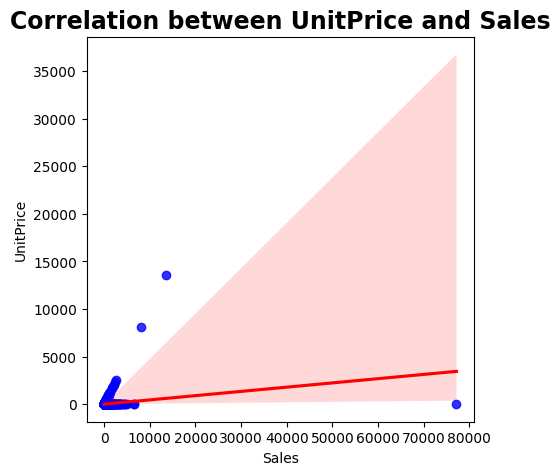

In [38]:
plt.figure(figsize=(5,5))
sns.regplot(
    x='Sales',
    y='UnitPrice',
    data=filtered_df,
    scatter_kws={'color':'blue'},
    line_kws={'color':'red'}
)
plt.title('Correlation between UnitPrice and Sales', fontsize=17, fontweight='bold')
plt.xlabel('Sales')
plt.ylabel('UnitPrice')
plt.show()



# **Conclusion**



The analysis reveals significant patterns in sales data. Sales activity appears to be concentrated between **10 AM and 3 PM**, with a **peak around 10-12** PM, indicating that this is the prime selling window.

The heatmap further refines this by showing how these peak hours vary or remain consistent across different months. Furthermore, the monthly sales chart clearly demonstrates seasonal variations, with sales generally **increasing** towards the **end of the year** (November and December showing the highest sales).

The pie chart identifies the top-selling products, which are crucial for focused sales efforts.

The correlation analysis provides insights into the relationship between unit price and sales. After handling irregular values and outliers, the relationship indicated a slightly positive trend, suggesting that pricing strategies may influence sales performance differently across products and customer segments.

Overall, these insights can be valuable for **optimizing operational strategies, inventory planning,** and **marketing efforts to maximize revenue**